In [1]:
import torch
import torch.nn as nn
import torch.optim as optoim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device", device)

Device cpu


In [3]:
data = "./Amaliy"

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=f"{data}/seg_train", transform=train_transform)
test_dataset = datasets.ImageFolder(root=f"{data}/seg_test", transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = train_dataset.classes

print("Sinflar: ", class_names)
print("Trainlar soni: ", len(train_dataset))
print("Testlar soni: ", len(test_dataset))

Sinflar:  ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Trainlar soni:  14034
Testlar soni:  3000


In [4]:
train_dataset.classes
# test_dataset.classes

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()

        self.fc1 = nn.Linear(32 * 32 * 32, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
model = SimpleCNN(num_classes=len(class_names)).to(device)
print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=32768, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=6, bias=True)
)


In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optoim.Adam(model.parameters(), lr=0.001)

In [7]:
num_epoch = 10

train_loss_history = []
train_acc_history = []
test_acc_history = []

for epoch in range(num_epoch):
    model.train()
    running_loss = 0.0
    corrent = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        corrent += (predicted == labels).sum().item()

    train_acc = 100 * corrent / total
    train_loss = running_loss / len(train_loader)

    # Har epochdan keyin test to'plamida ham baholaymiz (training curve uchun)
    model.eval()
    test_corrent = 0
    test_total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            test_total += labels.size(0)
            test_corrent += (predicted == labels).sum().item()
    epoch_test_acc = 100 * test_corrent / test_total

    train_loss_history.append(train_loss)
    train_acc_history.append(train_acc)
    test_acc_history.append(epoch_test_acc)

    print(f"Epoch [{epoch+1}/{num_epoch}], Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}%, Test Accuracy: {epoch_test_acc:.4f}%")

Epoch [1/10], Loss: 1.0475, Train Accuracy: 59.8831%, Test Accuracy: 70.9333%


Epoch [2/10], Loss: 0.7908, Train Accuracy: 70.8921%, Test Accuracy: 75.5333%


Epoch [3/10], Loss: 0.6964, Train Accuracy: 74.6402%, Test Accuracy: 79.2333%


Epoch [4/10], Loss: 0.6404, Train Accuracy: 76.6709%, Test Accuracy: 77.7000%


Epoch [5/10], Loss: 0.5941, Train Accuracy: 78.5378%, Test Accuracy: 78.0667%


Epoch [6/10], Loss: 0.5674, Train Accuracy: 79.5069%, Test Accuracy: 81.4333%


Epoch [7/10], Loss: 0.5316, Train Accuracy: 80.4831%, Test Accuracy: 81.2000%


Epoch [8/10], Loss: 0.5162, Train Accuracy: 81.0888%, Test Accuracy: 80.8333%


Epoch [9/10], Loss: 0.5077, Train Accuracy: 81.3239%, Test Accuracy: 81.3000%


Epoch [10/10], Loss: 0.4869, Train Accuracy: 82.3144%, Test Accuracy: 83.2000%


In [8]:
model.eval()
corrent = 0
total = 0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        corrent += (predicted == labels).sum().item()
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    test_acc = 100 * corrent / total
    print(f"Test Accuracy: {test_acc:.2f}%")

Test Accuracy: 83.20%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6051416].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.1134453].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9656862..2.0959384].


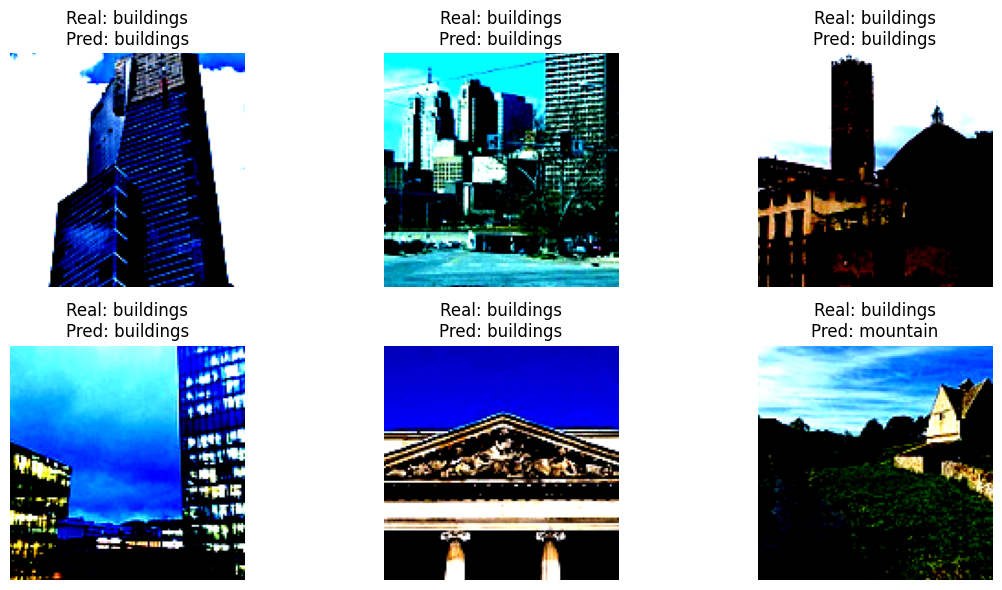

In [9]:
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

model.eval()
with torch.no_grad():
    outputs = model(images)
    _, predictions = torch.max(outputs, 1)

num_show = 6
plt.figure(figsize=(12, 6))
for i in range(num_show):
    img = images[i].cpu().permute(1, 2, 0).numpy()
    real_label = class_names[labels[i]]
    pred_label = class_names[predictions[i]]

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(f"Real: {real_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

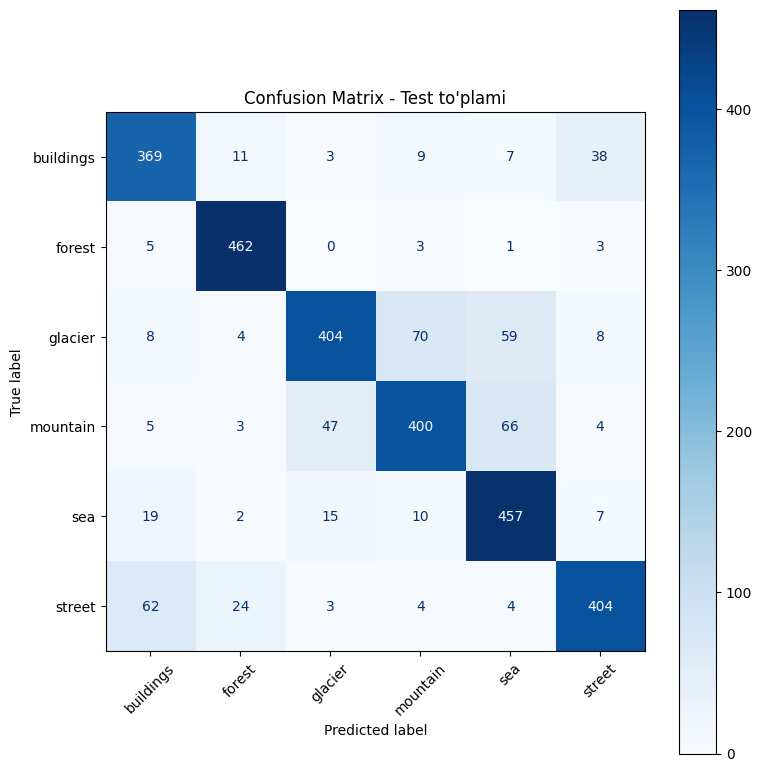

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix - Test to'plami")
plt.tight_layout()
plt.savefig("assets/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

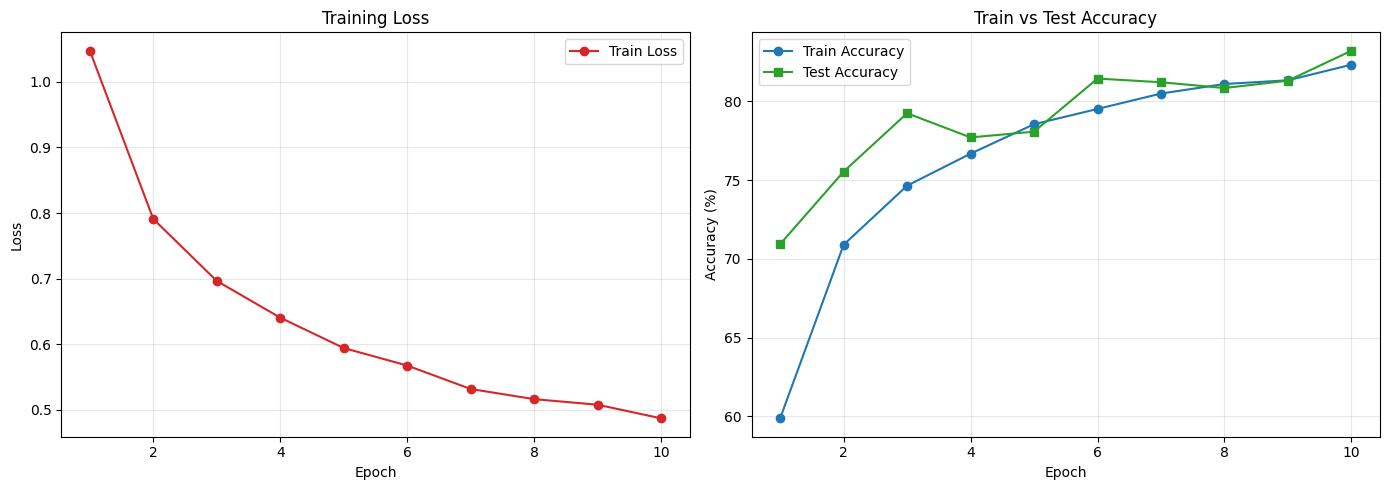

In [11]:
epochs_range = range(1, num_epoch + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_loss_history, marker="o", color="#d62728", label="Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(epochs_range, train_acc_history, marker="o", color="#1f77b4", label="Train Accuracy")
axes[1].plot(epochs_range, test_acc_history, marker="s", color="#2ca02c", label="Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Train vs Test Accuracy")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.savefig("assets/training_curve.png", dpi=150, bbox_inches="tight")
plt.show()